In [3]:
import sqlite3
import random

# Connect to (or create) the database
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

# Create the sales table
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")

# Define sample products and prices
products = {
    'Pen': 1.5,
    'Notebook': 3.0,
    'Eraser': 0.5,
    'Pencil': 1.0,
    'Marker': 2.0,
    'Scale': 1.2,
    'Highlighter': 2.5,
    'Stapler': 5.0
}

# Generate and insert 100 random sales records
data = []
for _ in range(100):
    product = random.choice(list(products.keys()))
    quantity = random.randint(1, 20)
    price = products[product]
    data.append((product, quantity, price))

cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", data)

# Commit and close
conn.commit()
conn.close()
print("sales_data.db created with 100 sales records.")


sales_data.db created with 100 sales records.


Sales Summary:

       product  total_quantity  total_revenue
0     Notebook             203          609.0
1      Stapler             118          590.0
2          Pen             375          562.5
3       Marker             178          356.0
4       Eraser             541          270.5
5  Highlighter              70          175.0
6        Scale             116          139.2
7       Pencil             108          108.0


<Figure size 1000x600 with 0 Axes>

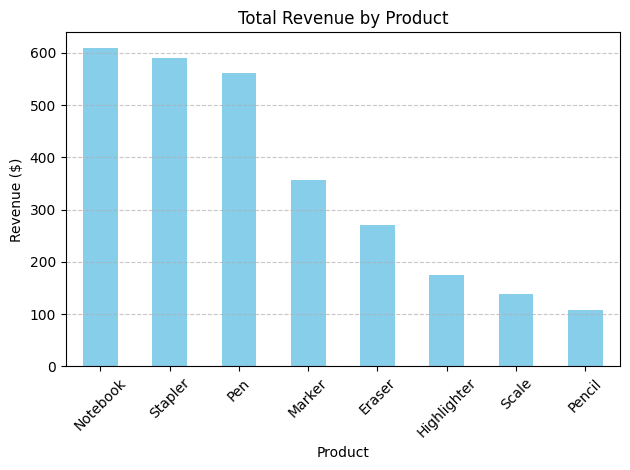

In [6]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the database
conn = sqlite3.connect("sales_data.db")

# SQL query to summarize total quantity and revenue per product
query = """
SELECT 
    product, 
    SUM(quantity) AS total_quantity, 
    ROUND(SUM(quantity * price), 2) AS total_revenue
FROM sales
GROUP BY product
ORDER BY total_revenue DESC
"""

# Load query results into a pandas DataFrame
df = pd.read_sql_query(query, conn)
conn.close()

# Print the DataFrame
print("Sales Summary:\n")
print(df)

# Plot revenue bar chart
plt.figure(figsize=(10, 6))
df.plot(kind='bar', x='product', y='total_revenue', color='skyblue', legend=False)
plt.title("Total Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save and show the chart
plt.savefig("sales_chart.png")
plt.show()
